In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


k_B = 1.380649e-23  # Boltzmann constant (J/K)
m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
P = 0.25 * 18.131842  # Pressure (Pascal)
r_D_e = 0.0016622715189364113

g = 9.8  # free fall acceleration (m/s^2)
rho = 1500  # mass density of dust particle
T_p = 300  # Kinetic temperature of dust particles motion
r_p = 4.445e-6  # Dust particle radius
m_p = 4.0 / 3.0 * np.pi * r_p**3 * rho

V_T_p = np.sqrt(2 * k_B * T_p / m_p)

In [30]:
def display_with_mean(
    ts: np.array, data: np.array, title: str, y_label: str, is_log=False, is_plot=False
):
    if is_plot:
        t_min = np.min(ts)
        t_max = np.max(ts)

        plt.figure(dpi=100)
        plt.title(f"{title}")
        plt.xlabel(r"$t, ns$")
        plt.ylabel(f"{y_label}")
        plt.grid()
        plt.plot(ts, data, "-")
        plt.hlines(
            np.mean(data[1_000:]),
            1.1 * t_min,
            t_max,
            colors="red",
            linestyles="--",
            label=f"{np.mean(data[1_000:]):10f}",
        )
        plt.legend(loc="best")
        plt.show()

    if is_log:
        return np.mean(data[1_000:]), np.std(np.log(data[1_000:]))
    else:
        return np.mean(data[1_000:]), np.std(data[1_000:])

In [31]:
rs1 = []
rs2 = []
traps = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

for i in traps:
    data = np.genfromtxt(f"../data/traps/data_{i}.txt", delimiter="\t")

    rs_1 = np.sqrt(np.square(data[:, 1]) + np.square(data[:, 2]))
    rs_2 = np.sqrt(np.square(data[:, 4]) + np.square(data[:, 5]))
    zs_1 = data[:, 3]
    vzs_1 = data[:, 6]

    vs_1 = np.sqrt(np.square(data[:, 7]) + np.square(data[:, 8]))
    vs_2 = np.sqrt(np.square(data[:, 7 + 3]) + np.square(data[:, 8 + 3]))
    zs_2 = data[:, 9]
    vzs_2 = data[:, 12]

    t = (data[:, 0]) / 2.0 * 50.0
    t_min = np.min(t)
    t_max = np.max(t)

    rs1 += [display_with_mean(t, rs_1, f"1st_{i}", "r, r_D_e")[0]]
    rs2 += [display_with_mean(t, rs_2, f"2nd_{i}", "r, r_D_e")[0]]
    # display_with_mean(t, vs_1, "1st", "v, m/s")
    # display_with_mean(t, vs_2, "2nd", "v, m/s")

    # display_with_mean(t, zs_1, "1st", "r, r_D_e")
    # display_with_mean(t, zs_2, "2nd", "r, r_D_e")
    # display_with_mean(t, vzs_1, "1st", "v, m/s")
    # display_with_mean(t, vzs_2, "2nd", "v, m/s")

rs1 = np.array(rs1)
rs2 = np.array(rs2)

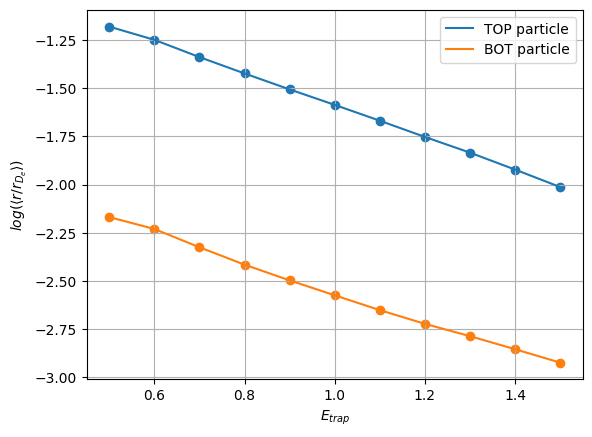

-0.8326203609156494
-0.7654024975555681


In [32]:
plt.figure(dpi=100)
plt.xlabel(r"$E_{trap}$")
plt.ylabel(r"$log(\left<r / r_{D_e}\right>)$")
plt.grid()
plt.plot(traps, np.log(rs1 / r_D_e), "-", label="TOP particle")
plt.plot(traps, np.log(rs2 / r_D_e), "-", label="BOT particle")
plt.scatter(
    traps,
    np.log(rs1 / r_D_e),
)
plt.scatter(
    traps,
    np.log(rs2 / r_D_e),
)
plt.legend(loc="best")
plt.show()

slope_1, _, _, _, _ = linregress(traps, np.log(rs1 / r_D_e))
slope_2, _, _, _, _ = linregress(traps, np.log(rs2 / r_D_e))

print(slope_1)
print(slope_2)

In [33]:
# from statsmodels.tsa.stattools import adfuller

_test = []

rs1 = []
rs2 = []
vs1 = []
vs2 = []
rs1_var = []
rs2_var = []
vs1_var = []
vs2_var = []

traps = np.array(
    [
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
        1.1,
        1.2,
        1.3,
        1.4,
        1.5,
        1.6,
        1.7,
        1.8,
        1.9,
        2.0,
    ]
)

for i in traps:
    data = np.genfromtxt(f"../data/new_traps/data_{i}.txt", delimiter="\t")

    rs_1 = np.sqrt(np.square(data[:, 1]) + np.square(data[:, 2]))
    rs_2 = np.sqrt(np.square(data[:, 4]) + np.square(data[:, 5]))
    zs_1 = data[:, 3]
    vzs_1 = data[:, 6]

    vs_1 = np.sqrt(np.square(data[:, 7]) + np.square(data[:, 8]))
    vs_2 = np.sqrt(np.square(data[:, 7 + 3]) + np.square(data[:, 8 + 3]))
    zs_2 = data[:, 9]
    vzs_2 = data[:, 12]

    t = (data[:, 0]) / 2.0 * 50.0
    t_min = np.min(t)
    t_max = np.max(t)

    k_B = 1.380649e-23  # Boltzmann constant (J/K)
    m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
    P = 0.25 * 18.131842  # Pressure (Pascal)
    r_D_e = 0.0016622715189364113

    mean1, var1 = display_with_mean(t, rs_1 / r_D_e, f"1st_{i}", "r, r_D_e")
    mean2, var2 = display_with_mean(t, rs_2 / r_D_e, f"2nd_{i}", "r, r_D_e")

    v_mean1, v_var1 = display_with_mean(t, vs_1, f"1st_{i}", "v, m/s")
    v_mean2, v_var2 = display_with_mean(t, vs_2, f"2nd_{i}", "v, m/s")

    rs1 += [mean1]
    rs2 += [mean2]
    rs1_var += [var1]
    rs2_var += [var2]

    vs1 += [v_mean1]
    vs2 += [v_mean2]
    vs1_var += [v_var1]
    vs2_var += [v_var2]


rs1 = np.array(rs1)
rs2 = np.array(rs2)
rs1_var = np.array(rs1_var)
rs2_var = np.array(rs2_var)

vs1 = np.array(vs1)
vs2 = np.array(vs2)
vs1_var = np.array(vs1_var)
vs2_var = np.array(vs2_var)

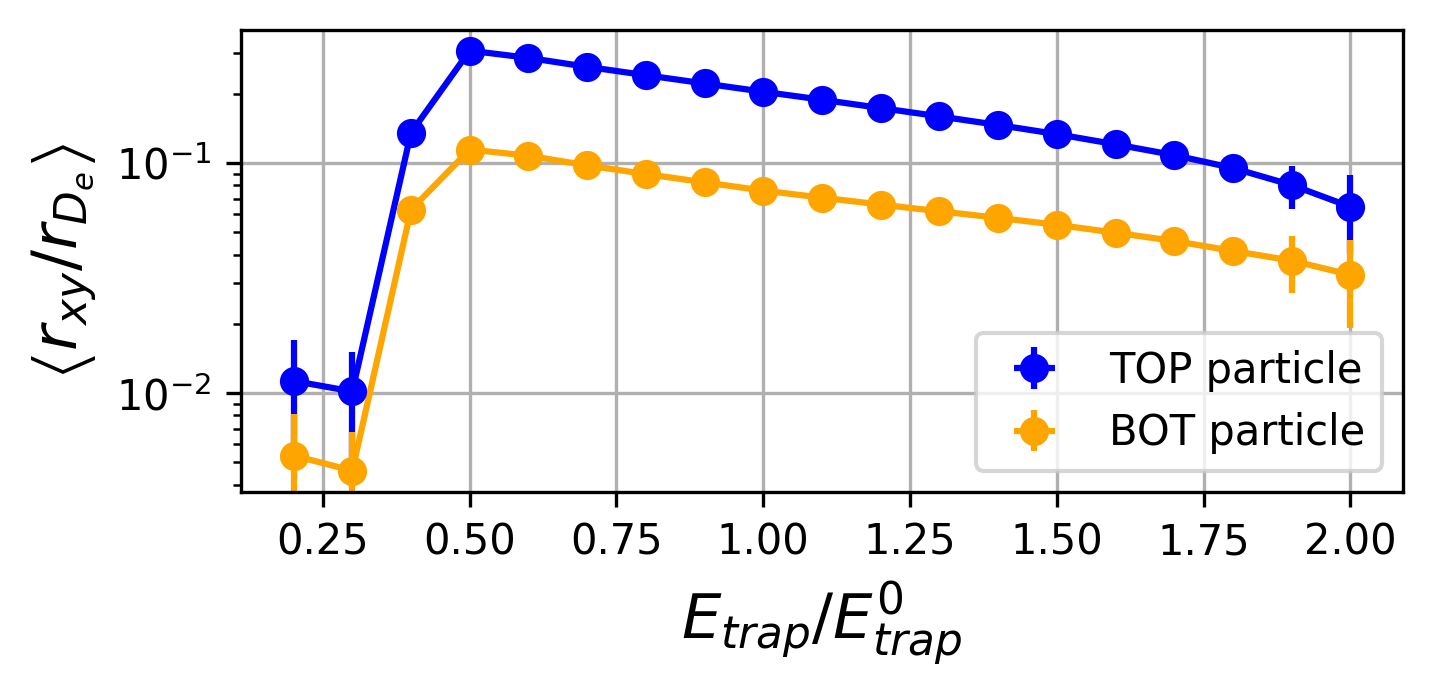

-0.8367363122757385
-0.7169121122250032


In [34]:
mask = traps > 0.1

plt.figure(dpi=300, figsize=(5, 2))
plt.xlabel(r"$E_{trap} / E_{trap}^0$", fontsize=15)
plt.ylabel(r"$\left<r_{xy} / r_{D_e}\right>$", fontsize=15)
plt.grid()
plt.yscale("log")
plt.errorbar(
    traps[mask], rs1[mask], rs1_var[mask], 0, "o", label="TOP particle", color="blue"
)
plt.errorbar(
    traps[mask], rs2[mask], rs2_var[mask], 0, "o", label="BOT particle", color="orange"
)
plt.plot(traps[mask], rs1[mask], "-", color="blue")
plt.plot(traps[mask], rs2[mask], "-", color="orange")
plt.legend(loc="best")
plt.show()

mask = np.logical_and(traps >= 0.75, traps <= 1.5)

slope_1, _, _, _, _ = linregress(traps[mask], np.log(rs1[mask] / r_D_e))
slope_2, _, _, _, _ = linregress(traps[mask], np.log(rs2[mask] / r_D_e))

print(slope_1)
print(slope_2)

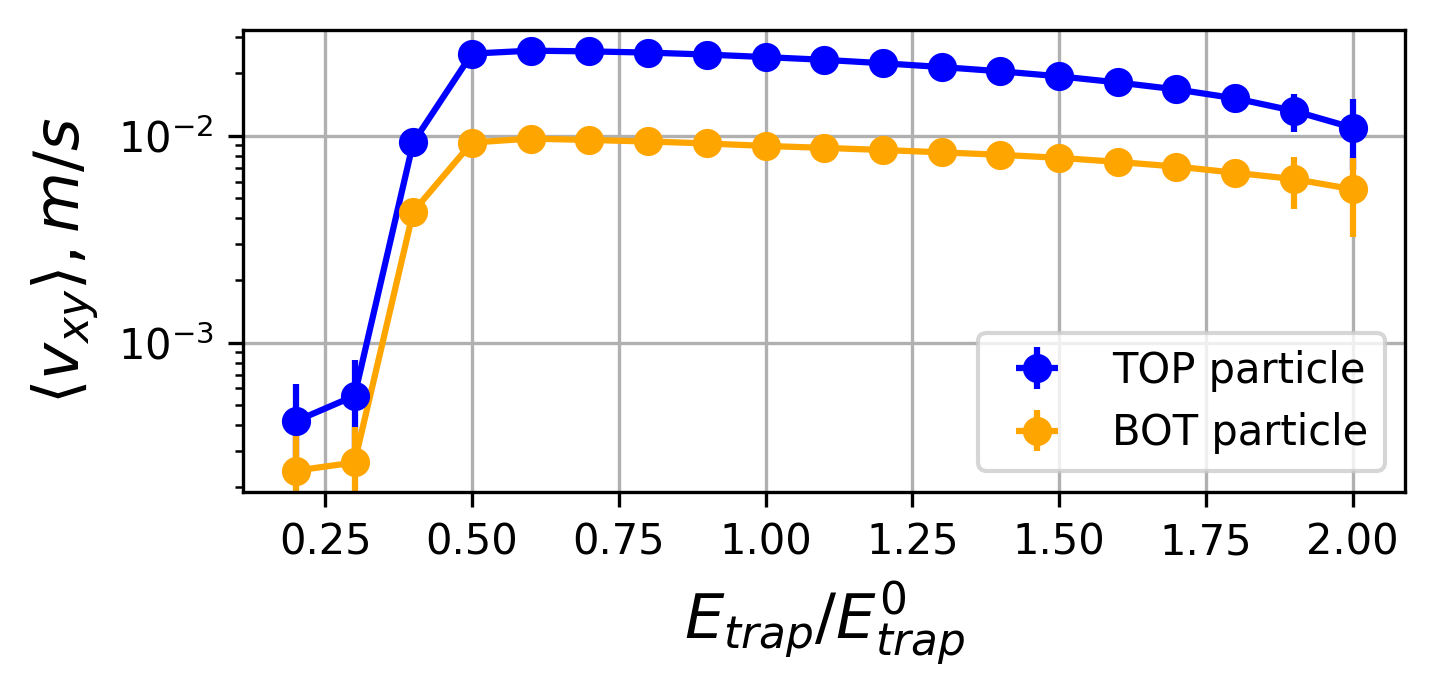

-0.008386566016441109
-0.0021929935577346864


In [35]:
mask = traps > 0.1

plt.figure(dpi=300, figsize=(5, 2))
plt.xlabel(r"$E_{trap} / E_{trap}^0$", fontsize=15)
plt.ylabel(r"$\left<v_{xy}\right>, m/s$", fontsize=15)
plt.grid()
plt.yscale("log")
plt.errorbar(
    traps[mask], vs1[mask], vs1_var[mask], 0, "o", label="TOP particle", color="blue"
)
plt.errorbar(
    traps[mask], vs2[mask], vs2_var[mask], 0, "o", label="BOT particle", color="orange"
)

plt.plot(traps[mask], vs1[mask], "-", color="blue")
plt.plot(traps[mask], vs2[mask], "-", color="orange")
plt.legend(loc="best")
plt.show()

mask = np.logical_and(traps >= 0.75, traps <= 1.5)

slope_1, _, _, _, _ = linregress(traps[mask], vs1[mask])
slope_2, _, _, _, _ = linregress(traps[mask], vs2[mask])

print(slope_1)
print(slope_2)

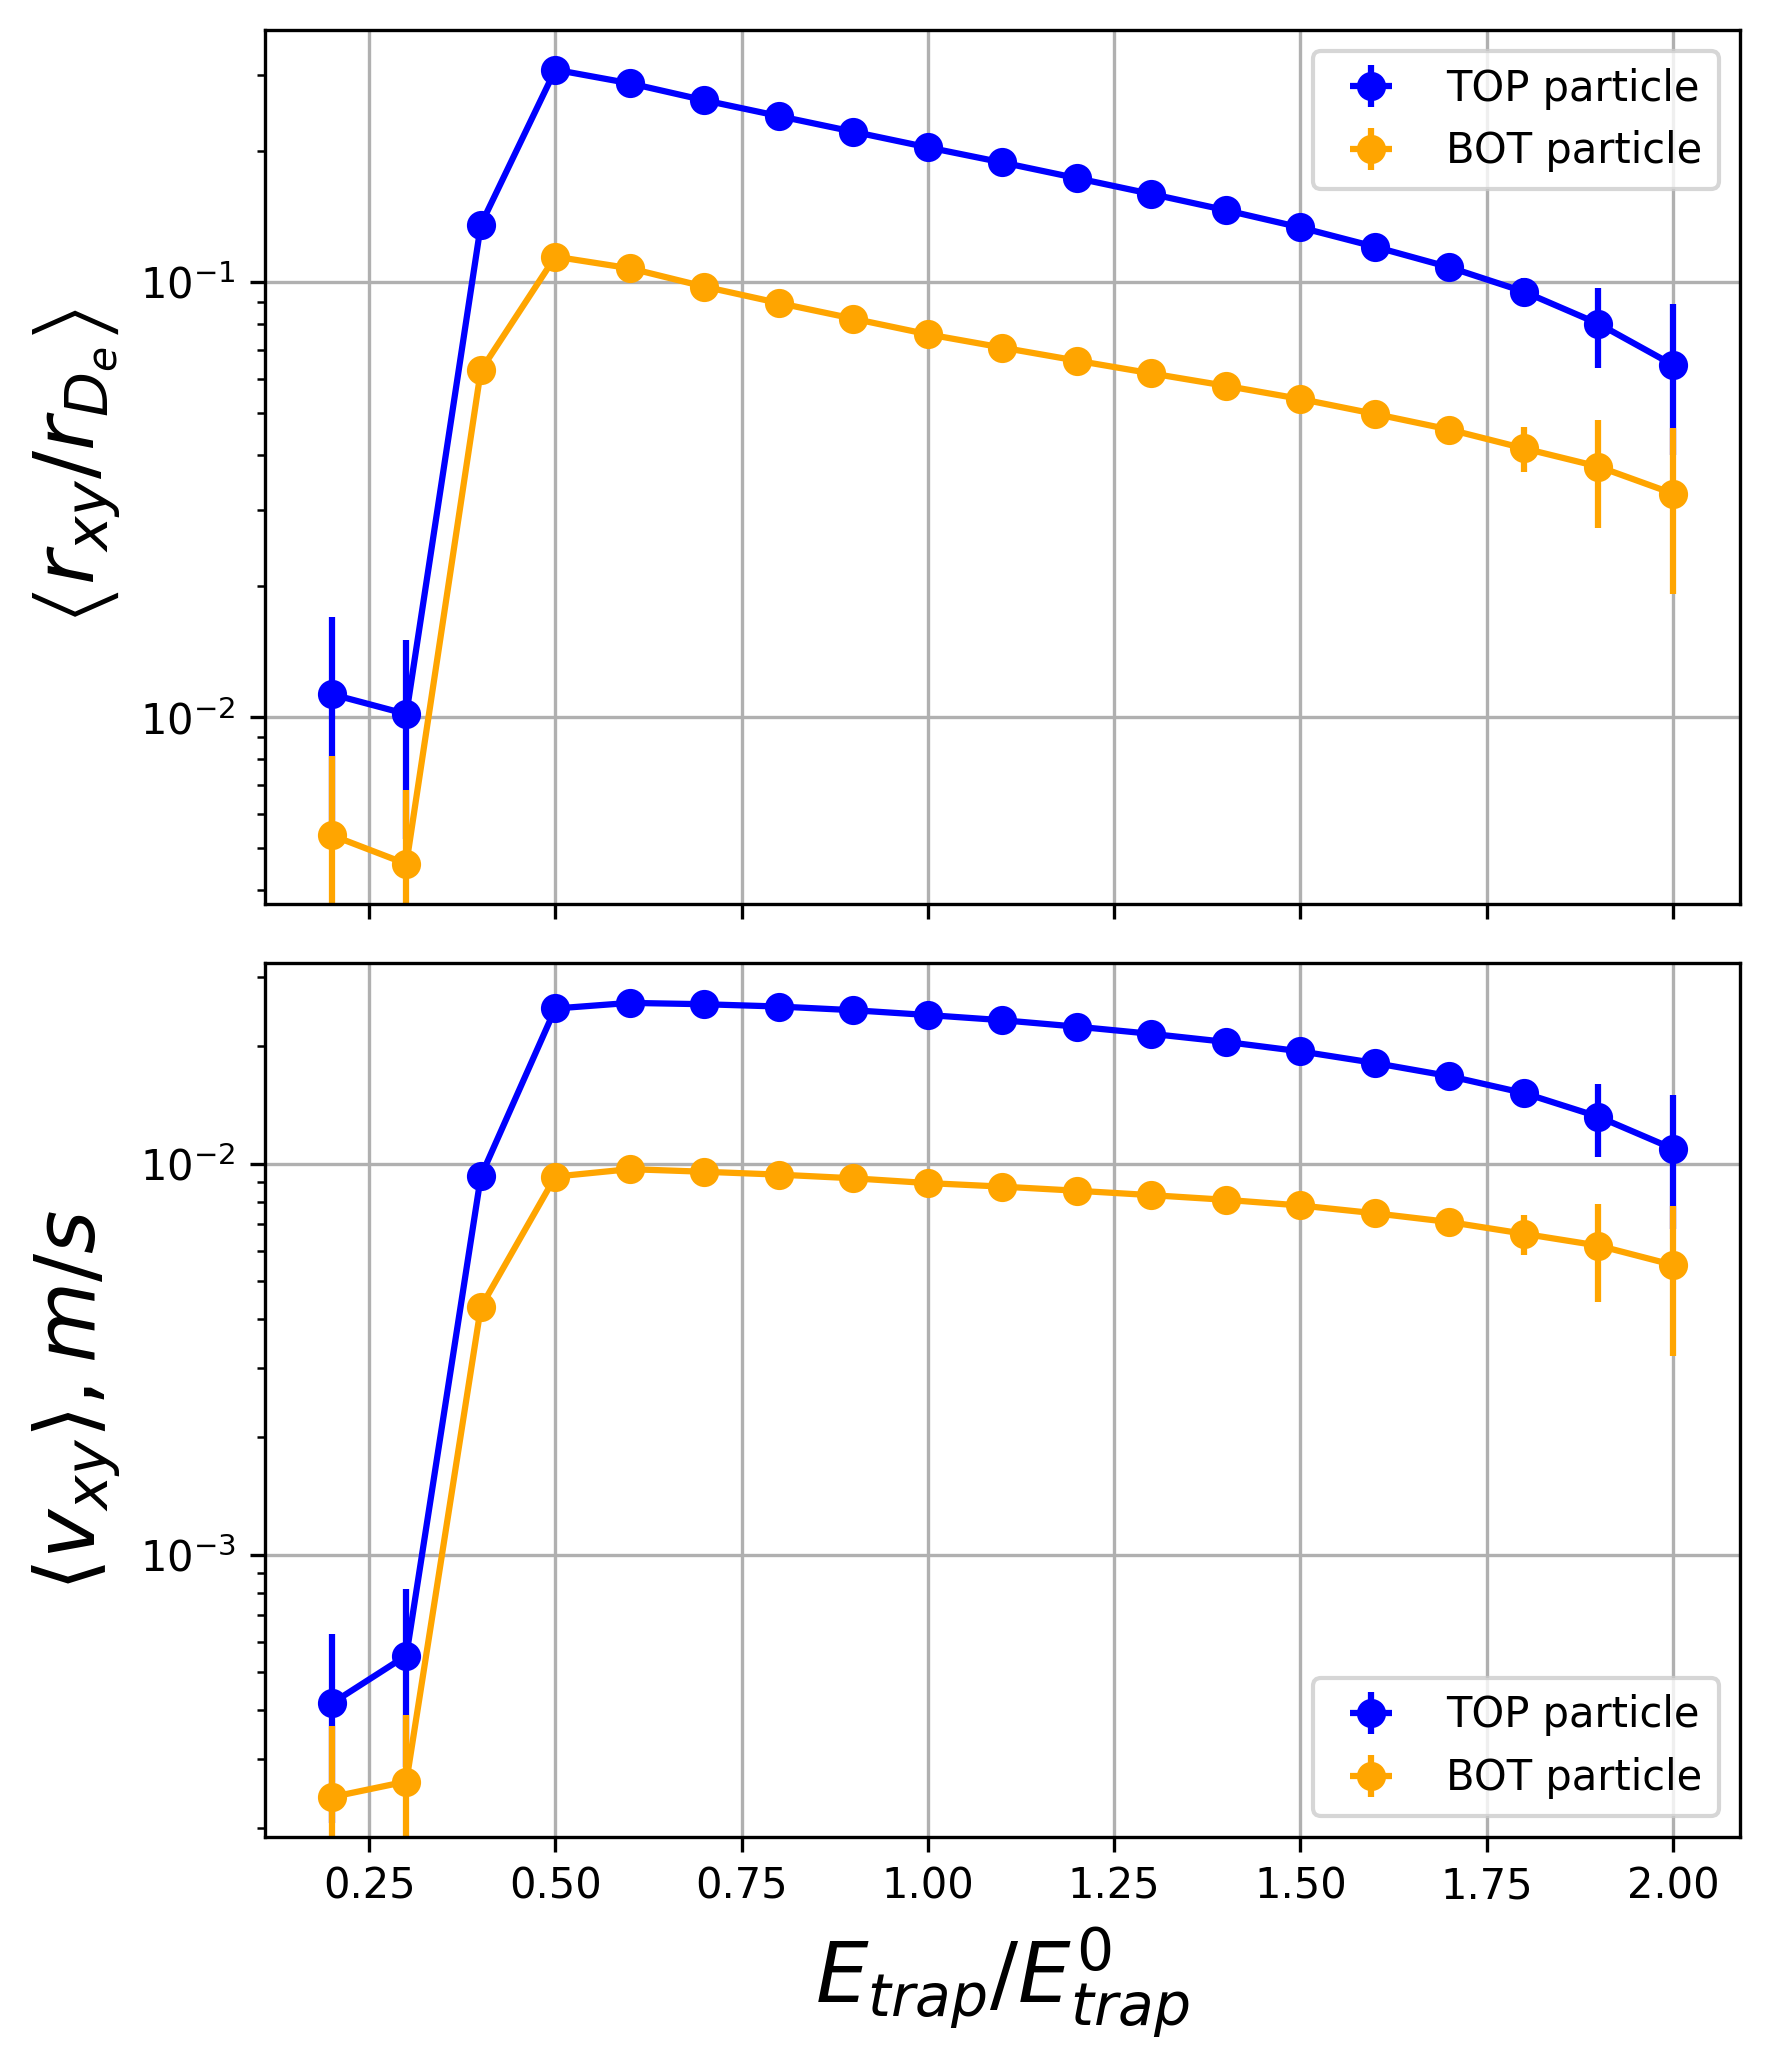

In [36]:
mask = traps > 0.1

# Создаем фигуру с двумя подграфиками (2 строки, 1 столбец)
fig, (ax1, ax2) = plt.subplots(2, 1, dpi=300, figsize=(6, 7), sharex=True)

# Первый график (верхний)
ax1.set_ylabel(r"$\left<r_{xy} / r_{D_e}\right>$", fontsize=20)
ax1.grid()
ax1.set_yscale("log")
ax1.errorbar(
    traps[mask], rs1[mask], rs1_var[mask], 0, "o", label="TOP particle", color="blue"
)
ax1.errorbar(
    traps[mask], rs2[mask], rs2_var[mask], 0, "o", label="BOT particle", color="orange"
)
ax1.plot(traps[mask], rs1[mask], "-", color="blue")
ax1.plot(traps[mask], rs2[mask], "-", color="orange")
ax1.legend(loc="best")

# Второй график (нижний)
ax2.set_ylabel(r"$\left<v_{xy}\right>, m/s$", fontsize=20)
ax2.grid()
ax2.set_yscale("log")
ax2.errorbar(
    traps[mask], vs1[mask], vs1_var[mask], 0, "o", label="TOP particle", color="blue"
)
ax2.errorbar(
    traps[mask], vs2[mask], vs2_var[mask], 0, "o", label="BOT particle", color="orange"
)
ax2.plot(traps[mask], vs1[mask], "-", color="blue")
ax2.plot(traps[mask], vs2[mask], "-", color="orange")
ax2.legend(loc="best")

# Общая подпись оси X (только для нижнего графика)
ax2.set_xlabel(r"$E_{trap} / E_{trap}^0$", fontsize=20)

# Автоматическая регулировка расстояния между графиками
plt.tight_layout()
plt.show()